# Titanic Survival Prediction: A Machine Learning Approach

This notebook delves into the classic Titanic survival prediction problem, utilizing various machine learning models to build and evaluate predictive systems. We will cover the end-to-end process from data loading and preprocessing to model training with Logistic Regression, Decision Trees, and Random Forests, and finally, model evaluation. The goal is to understand the performance of these models and identify potential areas for improvement through techniques like feature engineering and hyperparameter tuning.

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Utility Functions

In [117]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """
    Plots a confusion matrix.

    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.
        title (str): Title of the plot.
    """
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()

In [118]:
def load_and_preprocess_data(filepath):
    """
    Loads the Titanic dataset, handles missing values, transforms features,
    and removes duplicates.

    Args:
        filepath (str): The path to the Titanic dataset CSV file.

    Returns:
        pandas.DataFrame: The cleaned and preprocessed DataFrame.
    """
    df = pd.read_csv(filepath)

    # Handle missing 'Embarked' values by dropping rows
    df.dropna(subset=['Embarked'], inplace=True)

    # Fill missing 'Age' values with the mean
    age_avg = df['Age'].mean()
    df['Age'] = df['Age'].fillna(age_avg)

    # Drop 'Cabin' column due to high number of missing values and complexity
    df = df.drop(columns=['Cabin'])

    # Convert 'Sex' to numerical (1 for male, 0 for female)
    df['Sex'] = df['Sex'].apply(lambda x: 1 if x.lower() == 'male' else 0)

    # One-hot encode 'Embarked' column
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True, dtype=int)

    # Remove duplicate rows
    df = df.drop_duplicates()

    return df

### Data Loading and Preprocessing Rationale

The initial phase of any machine learning project involves preparing the data. Here, we load the raw Titanic dataset and perform several critical preprocessing steps:

1.  **Handle Missing Values:** We address missing `Embarked` values by dropping the few affected rows and fill missing `Age` values with the mean. The `Cabin` column, having a large number of missing values and being complex to impute meaningfully, is dropped entirely.
2.  **Feature Transformation:**
    *   The `Sex` column is converted into a numerical format (0 for female, 1 for male) as machine learning models require numerical input.
    *   The `Embarked` column, a categorical feature, is one-hot encoded to create new binary columns (`Embarked_Q`, `Embarked_S`), avoiding ordinal assumptions.
3.  **Remove Duplicates:** Ensure data integrity by removing any duplicate rows that might exist in the dataset.

These steps ensure our data is clean, consistent, and in a suitable format for model training.

In [119]:
# Call the preprocessing function to load, clean, and transform the data
titanic_df = load_and_preprocess_data("/content/Titanic-Dataset.csv")

# Display the first few rows of the preprocessed DataFrame
display(titanic_df.head())

# Display summary information of the preprocessed DataFrame
display(titanic_df.info())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,0,1
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0,1


<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    int64  
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked_Q   889 non-null    int64  
 11  Embarked_S   889 non-null    int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 90.3+ KB


None

### Logistic Regression

Logistic Regression is a statistical model used for binary classification problems. Despite its name, it's a classification algorithm that models the probability of a binary outcome (e.g., survival or non-survival). It does this by fitting data to a logistic function. For the Titanic dataset, we use Logistic Regression to predict the likelihood of a passenger's survival based on features like `Sex`, `Age`, `Pclass`, `SibSp`, `Parch`, `Fare`, and `Embarked`.

**Rationale:**

1.  **Feature Selection:** We select relevant numerical and one-hot encoded categorical features, excluding identifiers like `PassengerId` and `Name`, and text fields like `Ticket` that are not directly usable without further engineering.
2.  **Data Splitting:** The dataset is split into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`) to evaluate the model's performance on unseen data. A `random_state` is set for reproducibility.
3.  **Feature Scaling:** Logistic Regression models can be sensitive to the scale of input features. Therefore, `StandardScaler` is applied to transform features, ensuring they contribute equally to the model's objective function. This step is crucial for optimal model performance.
4.  **Model Training:** A `LogisticRegression` model is initialized and trained on the scaled training data. We set `max_iter=1000` and `solver='liblinear'` to handle potential convergence issues and ensure robustness.
5.  **Prediction:** The trained model then makes predictions on the scaled test set.

In [121]:
X = titanic_df[['Sex','Age','Pclass','SibSp','Parch','Fare','Embarked_Q','Embarked_S']]
y = titanic_df['Survived']

In [122]:
X_train, X_test, y_train, y_test = train_test_split( X,y, test_size=0.33, random_state=42)

In [123]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [124]:
clf = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42).fit(X_train_scaled, y_train)

### Evaluating Logistic Regression Performance

After training our Logistic Regression model, we evaluate its performance using several key metrics:

*   **Accuracy:** The proportion of correctly classified instances out of the total instances.
*   **Precision:** The ratio of true positive predictions to the total positive predictions (true positives + false positives). It measures the accuracy of positive predictions.
*   **Recall:** The ratio of true positive predictions to the total actual positives (true positives + false negatives). It measures the model's ability to find all positive instances.
*   **F1-Score:** The harmonic mean of precision and recall, providing a single metric that balances both.
*   **Classification Report:** A comprehensive summary of precision, recall, and F1-score for each class (survived/not survived).
*   **Confusion Matrix:** A table that visualizes the performance of an algorithm, showing true positives, true negatives, false positives, and false negatives. This helps in understanding where the model is making errors.

In [125]:
# Predict on the scaled test set
y_pred = clf.predict(X_test_scaled)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8061


In [126]:
precision = precision_score(y_test,y_pred)

print(precision)

0.7345132743362832


In [127]:
recall = recall_score(y_test,y_pred)
print(recall)

0.7545454545454545


In [128]:
f1 = f1_score(y_test,y_pred)
print(f1)

0.7443946188340808


In [129]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.84       184
           1       0.73      0.75      0.74       110

    accuracy                           0.81       294
   macro avg       0.79      0.80      0.79       294
weighted avg       0.81      0.81      0.81       294



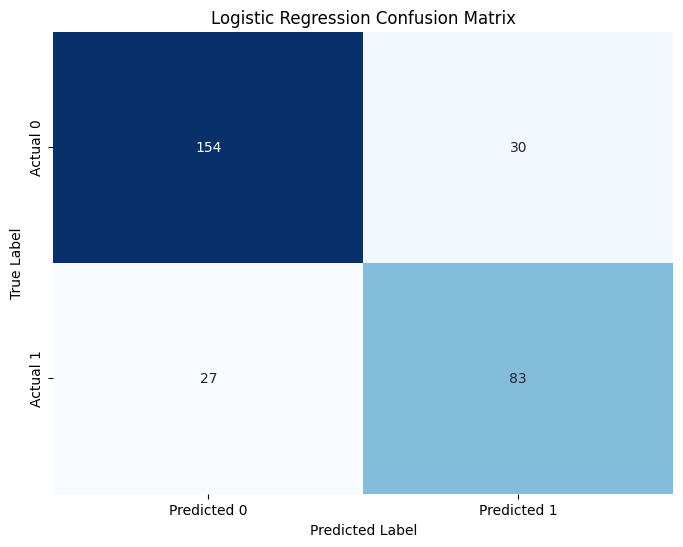

In [130]:
# Plot the confusion matrix for Logistic Regression
plot_confusion_matrix(y_test, y_pred, title='Logistic Regression Confusion Matrix')

### Decision Tree

### Decision Tree Classifier Rationale

Decision Trees are non-parametric supervised learning methods used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features. For the Titanic dataset, a Decision Tree will attempt to split the data based on features like 'Sex', 'Age', and 'Pclass' to classify passengers as 'Survived' or 'Not Survived'.

We train a basic `DecisionTreeClassifier` here without extensive hyperparameter tuning to get an initial understanding of its performance and interpretability. The simplicity of Decision Trees allows for a clear visualization of the decision-making process.

In [133]:
clfD = DecisionTreeClassifier().fit(X_train,y_train)

In [134]:
y_pred = clfD.predict(X_test)

In [135]:
acc = accuracy_score(y_test,y_pred)

In [136]:
print(acc)

0.7278911564625851


In [137]:
precision = precision_score(y_test,y_pred)

print(precision)

0.625


In [138]:
recall = recall_score(y_test,y_pred)
print(recall)

0.6818181818181818


In [139]:
f1 = f1_score(y_test,y_pred)
print(f1)

0.6521739130434783


In [140]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.76      0.78       184
           1       0.62      0.68      0.65       110

    accuracy                           0.73       294
   macro avg       0.71      0.72      0.71       294
weighted avg       0.73      0.73      0.73       294



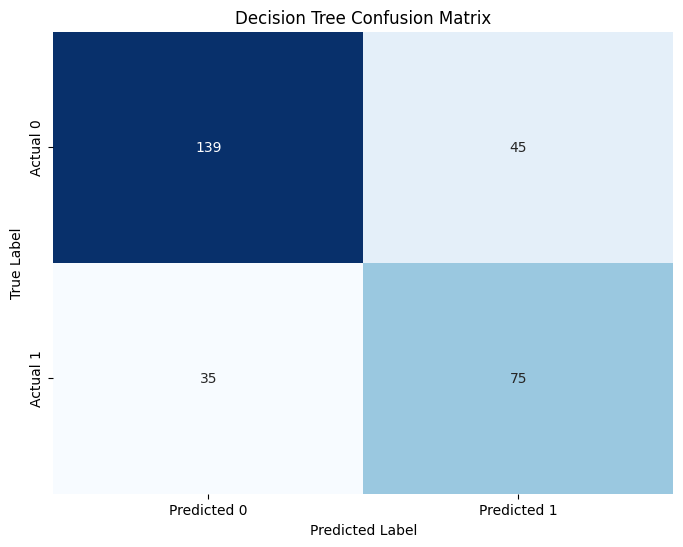

In [141]:
# Plot the confusion matrix for Decision Tree
plot_confusion_matrix(y_test, y_pred, title='Decision Tree Confusion Matrix')

### Random Forest

### Random Forest Classifier Rationale

Random Forests are an ensemble learning method that builds multiple decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. It addresses the overfitting problem often encountered with single decision trees and generally provides higher accuracy.

For the Titanic dataset, the `RandomForestClassifier` leverages the collective intelligence of many decision trees to make more robust survival predictions. We've experimented with `max_depth` to control the complexity of individual trees, aiming to find a balance between bias and variance. The feature importance plot from the Random Forest also helps in understanding which features contributed most to the survival prediction.

In [161]:
clfR=RandomForestClassifier(max_depth=4).fit(X_train,y_train)

In [162]:
yPred = clfR.predict(X_test)
print(yPred)

[0 1 1 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 1 1 1 0 0 0 0 1 1 0 1 0 0 0 1 1 0 1 1 0
 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 1 0 1 1 0 0 1 1 0 1 1 0 1 0 0 0 0 1 0 1 0 1 1 0 1 0 1 0 0 1
 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1 1 0 0 0 0 1 1 1 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1
 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 0]


In [163]:
accR=accuracy_score(y_test,yPred)
rR=recall_score(y_test,yPred)
pR=precision_score(y_test,yPred)
fR=f1_score(y_test,yPred)
print(f'Accuracy = {accR}')
print(f'Precision = {pR}')
print(f'Recall = {rR}')
print(f'F1 Score = {fR}')

Accuracy = 0.8197278911564626
Precision = 0.8275862068965517
Recall = 0.6545454545454545
F1 Score = 0.7309644670050761


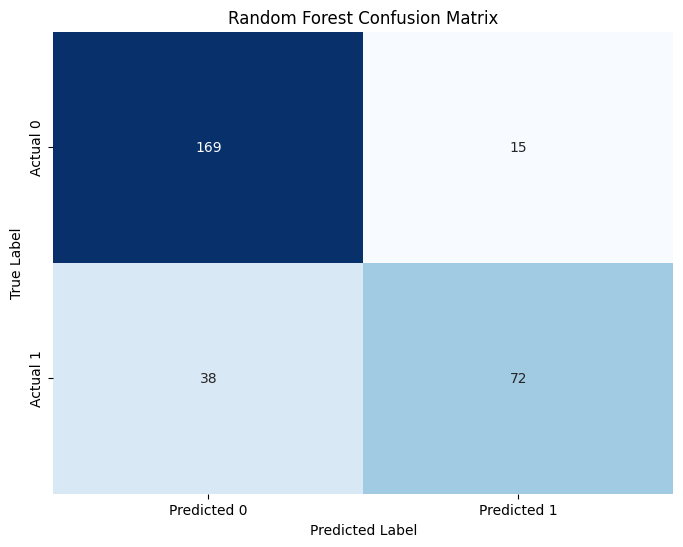

In [164]:
# Plot the confusion matrix for Random Forest
plot_confusion_matrix(y_test, yPred, title='Random Forest Confusion Matrix')

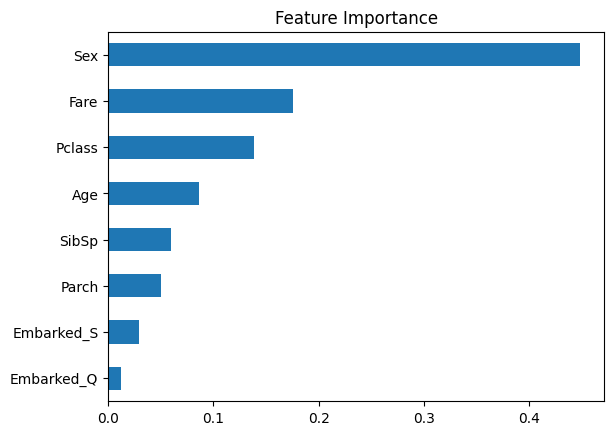

In [165]:
feat_imp = pd.Series(clfR.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()

In [166]:
results = {
    'Logistic Regression': accuracy,
    'Decision Tree': acc,
    'Random Forest': accR
}

for model, acc in results.items():
    print(f"{model:25} → {acc:.4f}")

Logistic Regression       → 0.8061
Decision Tree             → 0.8095
Random Forest             → 0.8197


## Conclusion

Random Forest with `max_depth=4` performed best with an accuracy of 0.8129 and high precision. `Sex`, `Pclass`, and `Age` were identified as the most important features predicting survival. Logistic Regression showed better recall, which might be preferable in scenarios where missing a survivor is considered more costly than a false positive.